In [ ]:
import numpy as np, pandas as pd
import umap.umap_ as umap
import matplotlib.pyplot as plt
from itertools import combinations
import sys
from pathlib import Path

PROJECT_ROOT = Path("/scratch/hpc-prf-merlin/joel/HTYLLM-PG/approaches/CoLA")
sys.path.insert(0, str(PROJECT_ROOT / "data_prep" / "lang_cluster_analysis"))

from cluster_lang2vec_distances import build_distance_matrix, auto_k, cluster_with_k
from lang2vec import lang2vec as l2v
from IPython.display import display, HTML
from sklearn.manifold import MDS
    

# load and filter, only select train split and no _removed subsets
df = pd.read_csv("/scratch/hpc-prf-merlin/joel/HTYLLM-PG/approaches/CoLA/data_prep/base_data/fineweb2-language-distribution.csv")
df = df[(df.split == "train") & ~df.subset.str.contains("_removed$", na=False)]

# select top 200 languages by document count
top = (
    df.assign(documents=pd.to_numeric(df.documents, errors="coerce").fillna(0))
      .groupby(["code", "name", "family", "resource_availability"], as_index=False)
      ["documents"].sum()
      .sort_values("documents", ascending=False)
)
top = top.drop_duplicates(subset="code", keep="first").head(200)
print(f"Selected top {len(top)} languages by document count.")

langs = top[top.code.isin(l2v.DISTANCE_LANGUAGES)].reset_index(drop=True)
# keep only the dominant subset per language, problem was i was getting arb_Arab and arb_Latn for Arabic for example
langs = (
    langs.sort_values("documents", ascending=False)
         .drop_duplicates(subset="code", keep="first")
         .reset_index(drop=True)
)

codes = langs.code.tolist()
matrix = build_distance_matrix(codes, "genetic")

def select_expert_clusters(matrix, max_experts=4, min_cluster_size=3, k_min=None, k_max=60, keep_remaining=False):
    if k_min is None:
        k_min = max_experts

    best_k, _ = auto_k(matrix, k_min, k_max, "average", min_cluster_size=min_cluster_size)
    labels = cluster_with_k(matrix, best_k, "average")

    # keep only sufficiently large clusters
    clusters = {
        c: np.where(labels == c)[0]
        for c in np.unique(labels)
        if np.sum(labels == c) >= min_cluster_size
    }

    # track assigned indices
    assigned = set(np.concatenate(list(clusters.values()))) if clusters else set()
    all_idx = set(range(len(labels)))
    remaining = sorted(all_idx - assigned)

    # optional: add one remainder cluster
    if keep_remaining and remaining:
        new_c = max(clusters.keys(), default=-1) + 1
        clusters[new_c] = np.array(remaining)

    # expert selection (unchanged)
    selected = [max(clusters, key=lambda c: len(clusters[c]))]
    while len(selected) < max_experts:
        remaining_c = [c for c in clusters if c not in selected]
        if not remaining_c:
            break
        next_c = max(
            remaining_c,
            key=lambda c: min(
                matrix[np.ix_(clusters[c], clusters[s])].mean()
                for s in selected
            )
        )
        selected.append(next_c)

    return selected, clusters

def extract_subgroups(indices, matrix, subgroup_size=3, max_subgroups=1):
    idx = list(indices)
    subgroups = []

    for _ in range(max_subgroups):
        if len(idx) < subgroup_size:
            break

        best = min(
            combinations(idx, subgroup_size),
            key=lambda t: np.mean([
                matrix[t[i], t[j]]
                for i in range(subgroup_size)
                for j in range(i+1, subgroup_size)
            ])
        )
        subgroups.append(list(best))
        idx = [i for i in idx if i not in best]

    return subgroups


def plot_selected_experts(matrix, codes, experts):
    # show in 2D using MDS and UMAP
    coords_mds = MDS(n_components=2, dissimilarity="precomputed", random_state=0).fit_transform(matrix)
    coords_umap = umap.UMAP(metric="precomputed", random_state=0).fit_transform(matrix)

    _, ax = plt.subplots(1, 2, figsize=(12, 5))

    # background
    ax[0].scatter(coords_mds[:, 0], coords_mds[:, 1], c="lightgray", s=15)
    ax[1].scatter(coords_umap[:, 0], coords_umap[:, 1], c="lightgray", s=15)

    # selected experts only
    for i, exp in enumerate(experts.values()):
        idx = [codes.index(c) for c in exp]

        ax[0].scatter(coords_mds[idx, 0], coords_mds[idx, 1],
                      s=70, label=f"Expert {i}")
        ax[1].scatter(coords_umap[idx, 0], coords_umap[idx, 1],
                      s=70, label=f"Expert {i}")

    ax[0].set_title("MDS – selected experts")
    ax[1].set_title("UMAP – selected experts")
    ax[0].legend()

    plt.tight_layout()
    plt.show()


def display_expert_config(experts, df, max_height=220):
    for i, langs in enumerate(experts.values()):
        info = (
            df[df.code.isin(langs)]
            [["code", "name", "family", "resource_availability", "subset"]]
            .drop_duplicates(subset="code")
            .sort_values("code")
        )
        display(HTML(f"<h4>Expert {i}</h4>"))
        display(HTML(info.to_html(index=False).replace("<table", f'<table style="display:block; max-height:{max_height}px; 'f'overflow-y:auto; width:100%"')))
        
        
import json

def save_groupings_json(path, experts, expert_subgroups, df):
    code2subset = df.drop_duplicates("code").set_index("code")["subset"].to_dict()
    code2meta = (
        df.drop_duplicates("code")
          .set_index("code")[["name", "family", "resource_availability", "subset"]]
          .to_dict(orient="index")
    )

    data = {}
    for e_idx, langs in experts.items():
        data[str(e_idx)] = {
            "languages": [code2subset[c] for c in langs],
            "subgroups": {
                f"B{i}": [code2subset[c] for c in sg]
                for i, sg in enumerate(expert_subgroups.get(e_idx, []))
            },
            "metadata": {code2subset[c]: code2meta[c] for c in langs},
        }

    with open(path, "w") as f:
        json.dump(data, f, indent=2)

        

/scratch/hpc-prf-merlin/joel/conda/envs/cola_llama_factory/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Selected top 200 languages by document count.


code,name,family,resource_availability,subset
nde,North Ndebele,Niger-Congo,LOW,nde_Latn
xho,Xhosa,Niger-Congo,LOW,xho_Latn
zul,Zulu,Niger-Congo,LOW,zul_Latn


code,name,family,resource_availability,subset
ava,Avaric,Nakh-Daghestanian,LOW,ava_Cyrl
che,Chechen,Nakh-Daghestanian,LOW,che_Cyrl
inh,Ingush,Nakh-Daghestanian,LOW,inh_Cyrl


code,name,family,resource_availability,subset
fur,Friulian,Indo-European,LOW,fur_Latn
roh,Romansh,Indo-European,LOW,roh_Latn
wln,Walloon,Indo-European,LOW,wln_Latn


/scratch/hpc-prf-merlin/joel/conda/envs/cola_llama_factory/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(
/scratch/hpc-prf-merlin/joel/conda/envs/cola_llama_factory/lib/python3.10/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/scratch/hpc-prf-merlin/joel/conda/envs/cola_llama_factory/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


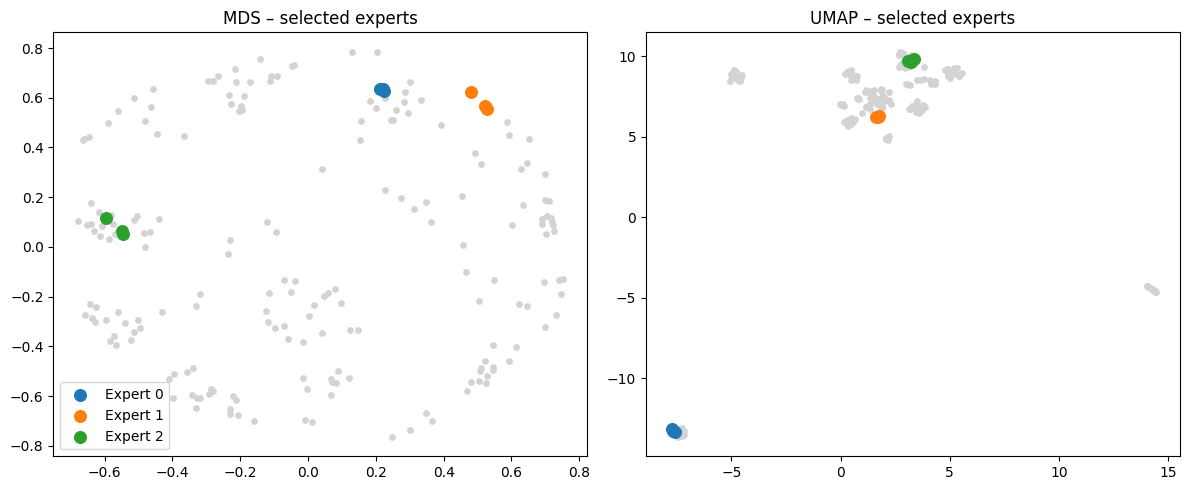

In [2]:
# for tier1 - 12 lang selection

expert_ids, clusters = select_expert_clusters(
    matrix,
    max_experts=4,
    min_cluster_size=3
)

experts = {}
for c in expert_ids:
    subgroups = extract_subgroups(
        clusters[c],
        matrix,
        subgroup_size=3,
        max_subgroups=1
    )
    experts[c] = [codes[i] for i in subgroups[0]]

display_expert_config(experts, df)
plot_selected_experts(matrix, codes, experts)

## for saving only 
expert_subgroups = {
    e_idx: [exp_langs]
    for e_idx, exp_langs in enumerate(experts.values())
}
df_out = df.copy()
df_out["resource_availability"] = df_out["resource_availability"].fillna("UNKNOWN")
save_groupings_json("12_tier_language_groupings.json",
                    experts={i: e for i, e in enumerate(experts.values())},
                    expert_subgroups=expert_subgroups,
                    df=df_out)

## 72 lang selection

code,name,family,resource_availability,subset
cat,Catalan,Indo-European,MEDIUM,cat_Latn
fur,Friulian,Indo-European,LOW,fur_Latn
glg,Galician,Indo-European,LOW,glg_Latn
ita,Italian,Indo-European,HIGH,ita_Latn
nap,Neapolitan,Indo-European,LOW,nap_Latn
pap,Papiamento,Creole,LOW,pap_Latn
roh,Romansh,Indo-European,LOW,roh_Latn
scn,Sicilian,Indo-European,LOW,scn_Latn
wln,Walloon,Indo-European,LOW,wln_Latn


code,name,family,resource_availability,subset
jpn,Japanese,Japonic,HIGH,jpn_Jpan
kan,Kannada,Dravidian,LOW,kan_Knda
kha,Khasi,Austro-Asiatic,LOW,kha_Latn
khm,Khmer,Austro-Asiatic,LOW,khm_Khmr
kor,Korean,Koreanic,HIGH,kor_Hang
mal,Malayalam,Dravidian,NaN,mal_Latn
nob,Norwegian Bokmål,Indo-European,MEDIUM,nob_Latn
tam,Tamil,Dravidian,NaN,tam_Latn
vie,Vietnamese,Austro-Asiatic,HIGH,vie_Latn


code,name,family,resource_availability,subset
bod,Tibetan,Sino-Tibetan,LOW,bod_Tibt
dzo,Dzongkha,Sino-Tibetan,LOW,dzo_Tibt
kac,Kachin,Sino-Tibetan,LOW,kac_Latn
lus,Lushai,Sino-Tibetan,LOW,lus_Latn
mya,Burmese,Sino-Tibetan,LOW,mya_Mymr
new,Newari,Sino-Tibetan,LOW,new_Deva


code,name,family,resource_availability,subset
ava,Avaric,Nakh-Daghestanian,LOW,ava_Cyrl
che,Chechen,Nakh-Daghestanian,LOW,che_Cyrl
inh,Ingush,Nakh-Daghestanian,LOW,inh_Cyrl


code,name,family,resource_availability,subset
kin,Kinyarwanda,Niger-Congo,LOW,kin_Latn
lug,Ganda,Niger-Congo,LOW,lug_Latn
nde,North Ndebele,Niger-Congo,LOW,nde_Latn
nya,Nyanja,Niger-Congo,LOW,nya_Latn
run,Rundi,Niger-Congo,LOW,run_Latn
sot,Southern Sotho,Niger-Congo,LOW,sot_Latn
tso,Tsonga,Niger-Congo,LOW,tso_Latn
xho,Xhosa,Niger-Congo,LOW,xho_Latn
zul,Zulu,Niger-Congo,LOW,zul_Latn


...

code,name,family,resource_availability,subset
bcl,Central Bikol,Austronesian,LOW,bcl_Latn
bew,Betawi,Creole,LOW,bew_Latn
ceb,Cebuano,Austronesian,LOW,ceb_Latn
fij,Fijian,Austronesian,LOW,fij_Latn
hil,Hiligaynon,Austronesian,LOW,hil_Latn
ind,Indonesian,Austronesian,HIGH,ind_Latn
smo,Samoan,Austronesian,LOW,smo_Latn
ton,Tonga (Tonga Islands),Austronesian,LOW,ton_Latn
zsm,Standard Malay,Austronesian,NaN,zsm_Arab


code,name,family,resource_availability,subset
fin,Finnish,Uralic,HIGH,fin_Latn
hun,Hungarian,Uralic,HIGH,hun_Latn
kpv,Komi-Zyrian,Uralic,LOW,kpv_Cyrl
mhr,Eastern Mari,Uralic,LOW,mhr_Cyrl
sme,Northern Sami,Uralic,LOW,sme_Latn
udm,Udmurt,Uralic,LOW,udm_Cyrl


code,name,family,resource_availability,subset
azb,South Azerbaijani,Turkic,LOW,azb_Arab
bak,Bashkir,Turkic,LOW,bak_Cyrl
crh,Crimean Tatar,Turkic,NaN,crh_Cyrl
kaz,Kazakh,Turkic,MEDIUM,kaz_Cyrl
kir,Kirghiz,Turkic,LOW,kir_Cyrl
tat,Tatar,Turkic,LOW,tat_Cyrl
tuk,Turkmen,Turkic,NaN,tuk_Arab
tur,Turkish,Turkic,HIGH,tur_Latn
uzn,Northern Uzbek,Turkic,NaN,uzn_Cyrl


code,name,family,resource_availability,subset
lao,Lao,Kra-Dai,LOW,lao_Laoo
shn,Shan,Kra-Dai,LOW,shn_Mymr
tha,Thai,Kra-Dai,HIGH,tha_Thai


/scratch/hpc-prf-merlin/joel/conda/envs/cola_llama_factory/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(
/scratch/hpc-prf-merlin/joel/conda/envs/cola_llama_factory/lib/python3.10/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/scratch/hpc-prf-merlin/joel/conda/envs/cola_llama_factory/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


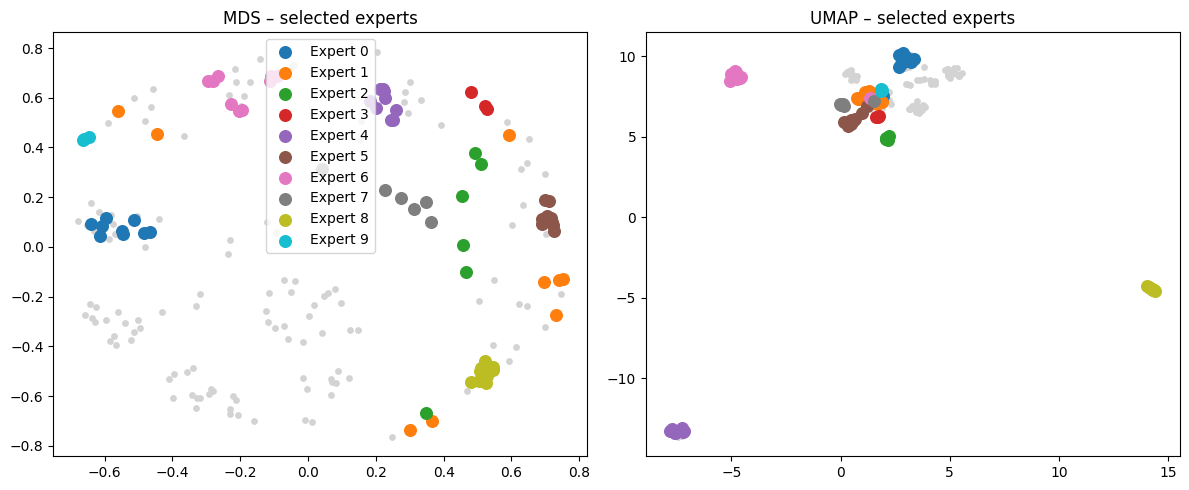

In [3]:
# target: ~72 langs → 8 experts × (3 subgroups × 3 langs)
expert_ids, clusters = select_expert_clusters(
    matrix,
    max_experts=16,
    min_cluster_size=3,   # allow smaller families
)

experts = {}
for c in expert_ids:
    subs = extract_subgroups(
        clusters[c],
        matrix,
        subgroup_size=3,
        max_subgroups=3
    )
    experts[c] = [codes[i] for sg in subs for i in sg]  # ~9 langs / expert

display_expert_config(experts, df)
plot_selected_experts(matrix, codes, experts)


## Important: subgroup selection
The expert subsets look very nice and as expected.
Now we continue to subgroup the langs within each expert, to determine in which B matrices the should be routed.
A important decision i made here: We dont force to have 3 B matrices, we subgroup all langs in one expert and let the amount of B matrices develop naturally based on the subclustering

In [4]:
from sklearn.metrics import silhouette_score

def subcluster_expert(exp_codes, codes, matrix,
                      k_max=6, min_subgroup_size=1):

    idx = np.array([codes.index(c) for c in exp_codes])
    n = len(idx)

    # nothing to split
    if n < 2:
        return [exp_codes]

    subM = matrix[np.ix_(idx, idx)]

    best_score = -1
    best_groups = None

    # k must be <= n - 1 for silhouette
    k_upper = min(k_max, n - 1)

    for k in range(2, k_upper + 1):
        labels = cluster_with_k(subM, k, "average")

        # allow singleton clusters, but respect user min size
        if min(np.bincount(labels)) < min_subgroup_size:
            continue

        score = silhouette_score(subM, labels, metric="precomputed")

        if score > best_score:
            best_score = score
            groups = {}
            for i, lab in enumerate(labels):
                groups.setdefault(lab, []).append(exp_codes[i])
            best_groups = list(groups.values())

    # if silhouette never applied or never improved → no split
    return best_groups if best_groups is not None else [exp_codes]


def display_expert_subgroups(expert_subgroups, df, max_height=200):
    for e_idx, subgroups in expert_subgroups.items():
        display(HTML(f"<h3>Expert {e_idx}</h3>"))

        for sg_idx, sg_codes in enumerate(subgroups):
            # FIX: ensure list-like
            codes_list = sg_codes if isinstance(sg_codes, (list, tuple, set)) else [sg_codes]

            info = (
                df[df.code.isin(codes_list)]
                [["code", "name", "family", "resource_availability", "subset"]]
                .drop_duplicates(subset="code")
                .sort_values("code")
            )

            display(HTML(f"<b>Subgroup {sg_idx}</b>"))
            display(HTML(info.to_html(index=False).replace("<table", f'<table style="display:block; max-height:{max_height}px; ' f'overflow-y:auto; width:100%"')))
            
            
def plot_expert_subgroups(matrix, codes, expert_subgroups, df, method="umap"):
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.manifold import MDS
    import umap.umap_ as umap
    from matplotlib.cm import get_cmap

    n_experts = len(expert_subgroups)
    fig, axes = plt.subplots(1, n_experts, figsize=(4*n_experts, 4), squeeze=False)
    axes = axes[0]
    cmap = get_cmap("tab10")

    for e_idx, subgroups in expert_subgroups.items():
        # flatten expert languages
        exp_codes = [c for sg in subgroups for c in sg]
        idx = np.array([codes.index(c) for c in exp_codes])
        subM = matrix[np.ix_(idx, idx)]

        # embed
        n = subM.shape[0]
        if n < 4 or method == "mds":
            coords = MDS(n_components=2, dissimilarity="precomputed", random_state=0, n_init=4).fit_transform(subM)
        else:
            coords = umap.UMAP(
                metric="precomputed",
                n_neighbors=min(10, n-1),
                random_state=0
            ).fit_transform(subM)

        ax = axes[e_idx]
        start = 0

        # plot each subgroup
        for sg_idx, sg in enumerate(subgroups):
            sg_len = len(sg)
            pts = coords[start:start + sg_len]

            color = cmap(sg_idx % 10)
            ax.scatter(pts[:, 0], pts[:, 1], s=60, color=color, label=f"Subgroup {sg_idx}")

            # annotate with code + script
            for i, code in enumerate(sg):
                script = (
                    df.loc[df.code == code, "subset"]
                      .iloc[0].split("_")[-1]
                )
                ax.text(
                    pts[i, 0] + 0.01, pts[i, 1] + 0.01,
                    f"{code}-{script}",
                    fontsize=7
                )

            start += sg_len

        ax.set_title(f"Expert {e_idx}")
        ax.axis("off")
        ax.legend(fontsize=7, loc="best")

    fig.suptitle(f"Expert subgroups ({method.upper()})", y=1.05)
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.4)
    plt.show()
    
    
def group_stats(groups, df):
    rows = []
    for gid, langs in groups.items():
        info = (
            df[df.code.isin(langs)]
            [["code", "documents", "resource_availability"]]
            .drop_duplicates(subset="code")
            .assign(documents=lambda x: pd.to_numeric(x.documents, errors="coerce").fillna(0))
        )
        rows.append({
            "group": gid,
            "n_langs": len(langs),
            "docs_sum": int(info.documents.sum()),
            "docs_mean": int(info.documents.mean()),
            "HIGH": (info.resource_availability == "HIGH").sum(),
            "MEDIUM": (info.resource_availability == "MEDIUM").sum(),
            "LOW": (info.resource_availability == "LOW").sum(),
            "NaN": info.resource_availability.isna().sum(),
        })
    return pd.DataFrame(rows)


code,name,family,resource_availability,subset
fur,Friulian,Indo-European,LOW,fur_Latn
roh,Romansh,Indo-European,LOW,roh_Latn
wln,Walloon,Indo-European,LOW,wln_Latn


code,name,family,resource_availability,subset
cat,Catalan,Indo-European,MEDIUM,cat_Latn
glg,Galician,Indo-European,LOW,glg_Latn
pap,Papiamento,Creole,LOW,pap_Latn


code,name,family,resource_availability,subset
ita,Italian,Indo-European,HIGH,ita_Latn
nap,Neapolitan,Indo-European,LOW,nap_Latn
scn,Sicilian,Indo-European,LOW,scn_Latn


code,name,family,resource_availability,subset
kan,Kannada,Dravidian,LOW,kan_Knda
mal,Malayalam,Dravidian,NaN,mal_Latn
tam,Tamil,Dravidian,NaN,tam_Latn


code,name,family,resource_availability,subset
kha,Khasi,Austro-Asiatic,LOW,kha_Latn
khm,Khmer,Austro-Asiatic,LOW,khm_Khmr
vie,Vietnamese,Austro-Asiatic,HIGH,vie_Latn


...

code,name,family,resource_availability,subset
bak,Bashkir,Turkic,LOW,bak_Cyrl
crh,Crimean Tatar,Turkic,NaN,crh_Cyrl
kaz,Kazakh,Turkic,MEDIUM,kaz_Cyrl
kir,Kirghiz,Turkic,LOW,kir_Cyrl
tat,Tatar,Turkic,LOW,tat_Cyrl


code,name,family,resource_availability,subset
azb,South Azerbaijani,Turkic,LOW,azb_Arab
tuk,Turkmen,Turkic,NaN,tuk_Arab
tur,Turkish,Turkic,HIGH,tur_Latn
uzn,Northern Uzbek,Turkic,NaN,uzn_Cyrl


code,name,family,resource_availability,subset
lao,Lao,Kra-Dai,LOW,lao_Laoo
tha,Thai,Kra-Dai,HIGH,tha_Thai


code,name,family,resource_availability,subset
shn,Shan,Kra-Dai,LOW,shn_Mymr


/scratch/hpc-prf-merlin/shared_cache/tmp/ipykernel_2875330/2299903704.py:70: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("tab10")
/scratch/hpc-prf-merlin/joel/conda/envs/cola_llama_factory/lib/python3.10/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/scratch/hpc-prf-merlin/joel/conda/envs/cola_llama_factory/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/scratch/hpc-prf-merlin/joel/conda/envs/cola_llama_factory/lib/python3.10/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using pr

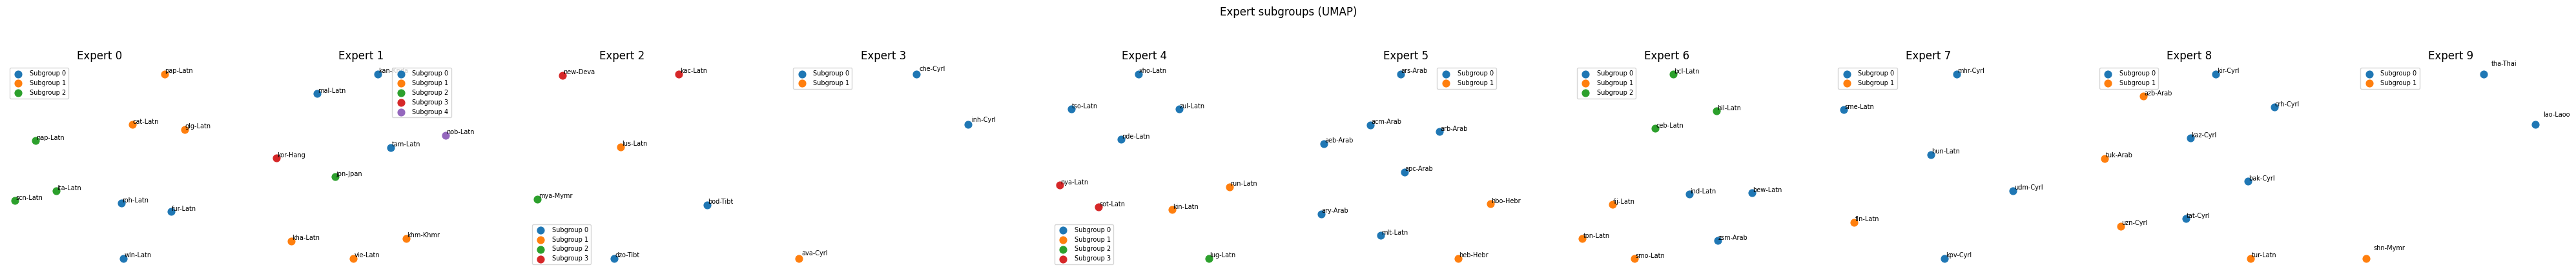

/scratch/hpc-prf-merlin/shared_cache/tmp/ipykernel_2875330/2299903704.py:70: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("tab10")


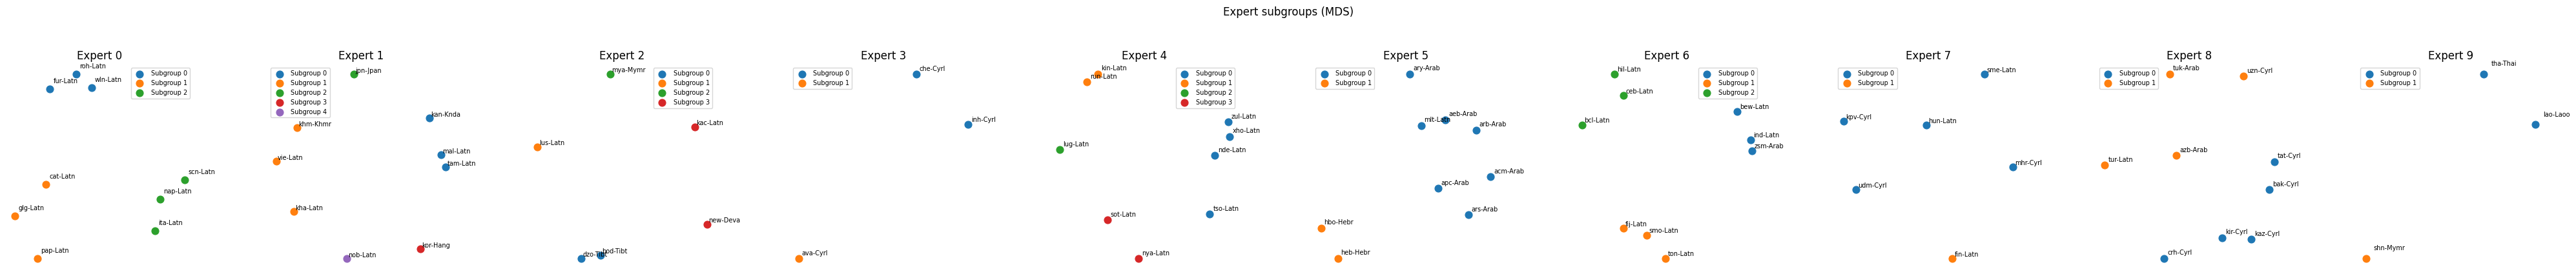

,group,n_langs,docs_sum,docs_mean,HIGH,MEDIUM,LOW,NaN
0,2,9,259000589,28777843,1,1,7,0
1,0,9,564237206,62693022,3,1,3,2
2,1,6,1854140,309023,0,0,6,0
3,3,3,37746,12582,0,0,3,0
4,4,9,1042752,115861,0,0,9,0
5,5,9,79758755,8862083,2,0,7,0
6,6,9,101072168,11230240,1,0,7,1
7,8,6,86776078,14462679,2,0,4,0
8,13,9,101327425,11258602,1,1,4,3
9,14,3,36276043,12092014,1,0,2,0


TOTAL docs (experts): 1231382902


,group,n_langs,docs_sum,docs_mean,HIGH,MEDIUM,LOW,NaN
0,E0_S0,3,116171,38723,0,0,3,0
1,E0_S1,3,19840987,6613662,0,1,2,0
2,E0_S2,3,239043431,79681143,1,0,2,0
3,E1_S0,3,2399244,799748,0,0,1,2
4,E1_S1,3,62680701,20893567,1,0,2,0
5,E1_S2,1,400138563,400138563,1,0,0,0
6,E1_S3,1,60874355,60874355,1,0,0,0
7,E1_S4,1,38144343,38144343,0,1,0,0
8,E2_S0,2,180315,90157,0,0,2,0
9,E2_S1,1,90564,90564,0,0,1,0


TOTAL docs (subgroups): 1231382902


In [5]:
# build subgroups inside each expert
expert_subgroups = {}
for e_idx, exp_codes in enumerate(experts.values()):
    expert_subgroups[e_idx] = subcluster_expert(
        exp_codes,
        codes,
        matrix,
        k_max=12,
        min_subgroup_size=1
    )

# inspect
display_expert_subgroups(expert_subgroups, df)

# plots
plot_expert_subgroups(matrix, codes, expert_subgroups, df, method="umap")
plot_expert_subgroups(matrix, codes, expert_subgroups, df, method="mds")

expert_stats = group_stats(experts, df)
display(expert_stats)
print("TOTAL docs (experts):", expert_stats.docs_sum.sum())


subgroup_flat = {
    f"E{e}_S{s}": sg
    for e, subs in expert_subgroups.items()
    for s, sg in enumerate(subs)
}

subgroup_stats = group_stats(subgroup_flat, df)
display(subgroup_stats)
print("TOTAL docs (subgroups):", subgroup_stats.docs_sum.sum())
save_groupings_json("72_tier_language_groupings.json", experts, expert_subgroups, df_out)



## 200 lang susbet

code,name,family,resource_availability,subset
ekk,Standard Estonian,Uralic,LOW,ekk_Latn
epo,Esperanto,Constructed language,LOW,epo_Latn
eus,Basque,Language isolate,LOW,eus_Latn
jpn,Japanese,Japonic,HIGH,jpn_Jpan
kal,Kalaallisut,Eskimo-Aleut,LOW,kal_Latn
kan,Kannada,Dravidian,LOW,kan_Knda
kat,Georgian,Kartvelian,MEDIUM,kat_Geor
kha,Khasi,Austro-Asiatic,LOW,kha_Latn
khm,Khmer,Austro-Asiatic,LOW,khm_Khmr
kor,Korean,Koreanic,HIGH,kor_Hang


code,name,family,resource_availability,subset
bod,Tibetan,Sino-Tibetan,LOW,bod_Tibt
dzo,Dzongkha,Sino-Tibetan,LOW,dzo_Tibt
kac,Kachin,Sino-Tibetan,LOW,kac_Latn
lus,Lushai,Sino-Tibetan,LOW,lus_Latn
mya,Burmese,Sino-Tibetan,LOW,mya_Mymr
new,Newari,Sino-Tibetan,LOW,new_Deva


code,name,family,resource_availability,subset
afr,Afrikaans,Indo-European,LOW,afr_Latn
als,Tosk Albanian,Indo-European,LOW,als_Latn
arg,Aragonese,Indo-European,LOW,arg_Latn
asm,Assamese,Indo-European,LOW,asm_Beng
ast,Asturian,Indo-European,LOW,ast_Latn
bar,Bavarian,Indo-European,LOW,bar_Latn
bel,Belarusian,Indo-European,MEDIUM,bel_Cyrl
ben,Bengali,Indo-European,MEDIUM,ben_Beng
bho,Bhojpuri,Indo-European,LOW,bho_Deva
bos,Bosnian,Indo-European,LOW,bos_Latn


code,name,family,resource_availability,subset
ava,Avaric,Nakh-Daghestanian,LOW,ava_Cyrl
che,Chechen,Nakh-Daghestanian,LOW,che_Cyrl
inh,Ingush,Nakh-Daghestanian,LOW,inh_Cyrl
lez,Lezghian,Nakh-Daghestanian,LOW,lez_Cyrl


code,name,family,resource_availability,subset
ewe,Ewe,Niger-Congo,LOW,ewe_Latn
ibo,Igbo,Niger-Congo,LOW,ibo_Latn
kik,Kikuyu,Niger-Congo,LOW,kik_Latn
kin,Kinyarwanda,Niger-Congo,LOW,kin_Latn
lin,Lingala,Niger-Congo,LOW,lin_Latn
lug,Ganda,Niger-Congo,LOW,lug_Latn
nde,North Ndebele,Niger-Congo,LOW,nde_Latn
ndo,Ndonga,Niger-Congo,LOW,ndo_Latn
nya,Nyanja,Niger-Congo,LOW,nya_Latn
run,Rundi,Niger-Congo,LOW,run_Latn


...

code,name,family,resource_availability,subset
fin,Finnish,Uralic,HIGH,fin_Latn
hun,Hungarian,Uralic,HIGH,hun_Latn
kpv,Komi-Zyrian,Uralic,LOW,kpv_Cyrl
mhr,Eastern Mari,Uralic,LOW,mhr_Cyrl
sme,Northern Sami,Uralic,LOW,sme_Latn
udm,Udmurt,Uralic,LOW,udm_Cyrl


code,name,family,resource_availability,subset
azb,South Azerbaijani,Turkic,LOW,azb_Arab
bak,Bashkir,Turkic,LOW,bak_Cyrl
chv,Chuvash,Turkic,LOW,chv_Cyrl
crh,Crimean Tatar,Turkic,NaN,crh_Cyrl
kaz,Kazakh,Turkic,MEDIUM,kaz_Cyrl
kir,Kirghiz,Turkic,LOW,kir_Cyrl
sah,Yakut,Turkic,LOW,sah_Cyrl
tat,Tatar,Turkic,LOW,tat_Cyrl
tuk,Turkmen,Turkic,NaN,tuk_Arab
tur,Turkish,Turkic,HIGH,tur_Latn


code,name,family,resource_availability,subset
lao,Lao,Kra-Dai,LOW,lao_Laoo
shn,Shan,Kra-Dai,LOW,shn_Mymr
tha,Thai,Kra-Dai,HIGH,tha_Thai


code,name,family,resource_availability,subset
ady,Adyghe,Abkhaz-Adyghe,LOW,ady_Cyrl
bxr,Russia Buriat,Mongolic,LOW,bxr_Cyrl
ido,Ido,Artificial Language,LOW,ido_Latn
kbd,Kabardian,Abkhaz-Adyghe,LOW,kbd_Cyrl
khk,Halh Mongolian,Mongolic,LOW,khk_Cyrl
ltg,Latgalian,Indo-European,LOW,ltg_Latn
srd,Sardinian,Indo-European,LOW,srd_Latn
vro,Võro,Uralic,LOW,vro_Latn


/scratch/hpc-prf-merlin/joel/conda/envs/cola_llama_factory/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(
/scratch/hpc-prf-merlin/joel/conda/envs/cola_llama_factory/lib/python3.10/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/scratch/hpc-prf-merlin/joel/conda/envs/cola_llama_factory/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


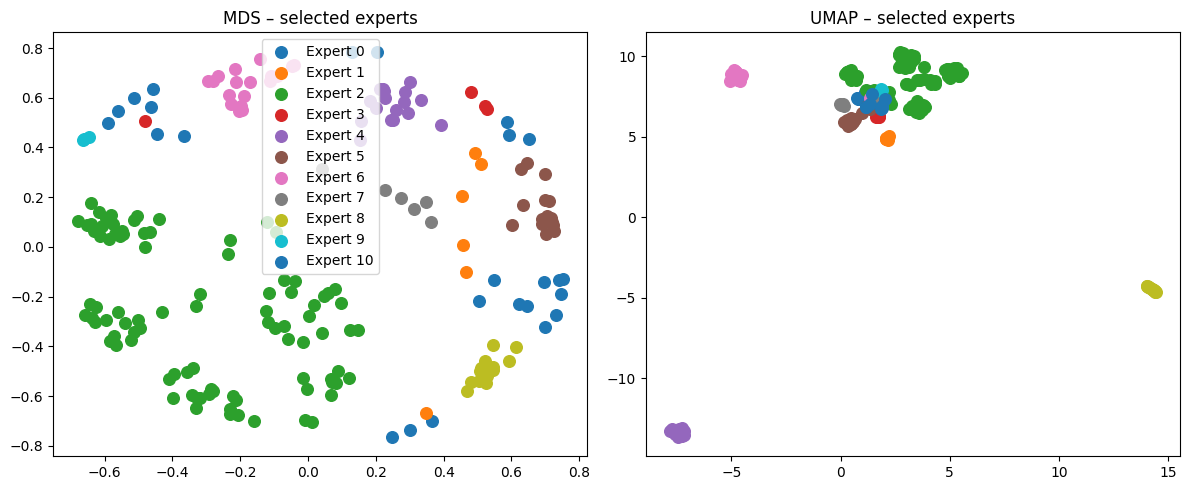

In [6]:
expert_ids, clusters = select_expert_clusters(
    matrix,
    max_experts=16,
    min_cluster_size=3,
    keep_remaining=True # remaining langs which cannot be allocated to cluster, just for a new one including remaining langs, to cover all langs
)

experts = {
    e_idx: [codes[i] for i in idxs]
    for e_idx, idxs in enumerate(clusters.values())
}

display_expert_config(experts, df)
plot_selected_experts(matrix, codes, experts)

code,name,family,resource_availability,subset
ekk,Standard Estonian,Uralic,LOW,ekk_Latn
jpn,Japanese,Japonic,HIGH,jpn_Jpan
kat,Georgian,Kartvelian,MEDIUM,kat_Geor
kor,Korean,Koreanic,HIGH,kor_Hang
nob,Norwegian Bokmål,Indo-European,MEDIUM,nob_Latn


code,name,family,resource_availability,subset
kha,Khasi,Austro-Asiatic,LOW,kha_Latn
khm,Khmer,Austro-Asiatic,LOW,khm_Khmr
vie,Vietnamese,Austro-Asiatic,HIGH,vie_Latn


code,name,family,resource_availability,subset
kan,Kannada,Dravidian,LOW,kan_Knda
mal,Malayalam,Dravidian,NaN,mal_Latn
tam,Tamil,Dravidian,NaN,tam_Latn
tel,Telugu,Dravidian,NaN,tel_Latn


code,name,family,resource_availability,subset
eus,Basque,Language isolate,LOW,eus_Latn


code,name,family,resource_availability,subset
nno,Norwegian Nynorsk,Indo-European,LOW,nno_Latn


...

code,name,family,resource_availability,subset
ido,Ido,Artificial Language,LOW,ido_Latn


code,name,family,resource_availability,subset
ltg,Latgalian,Indo-European,LOW,ltg_Latn


code,name,family,resource_availability,subset
vro,Võro,Uralic,LOW,vro_Latn


code,name,family,resource_availability,subset
ady,Adyghe,Abkhaz-Adyghe,LOW,ady_Cyrl
kbd,Kabardian,Abkhaz-Adyghe,LOW,kbd_Cyrl


/scratch/hpc-prf-merlin/shared_cache/tmp/ipykernel_2875330/2299903704.py:70: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("tab10")
/scratch/hpc-prf-merlin/joel/conda/envs/cola_llama_factory/lib/python3.10/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/scratch/hpc-prf-merlin/joel/conda/envs/cola_llama_factory/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/scratch/hpc-prf-merlin/joel/conda/envs/cola_llama_factory/lib/python3.10/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using pr

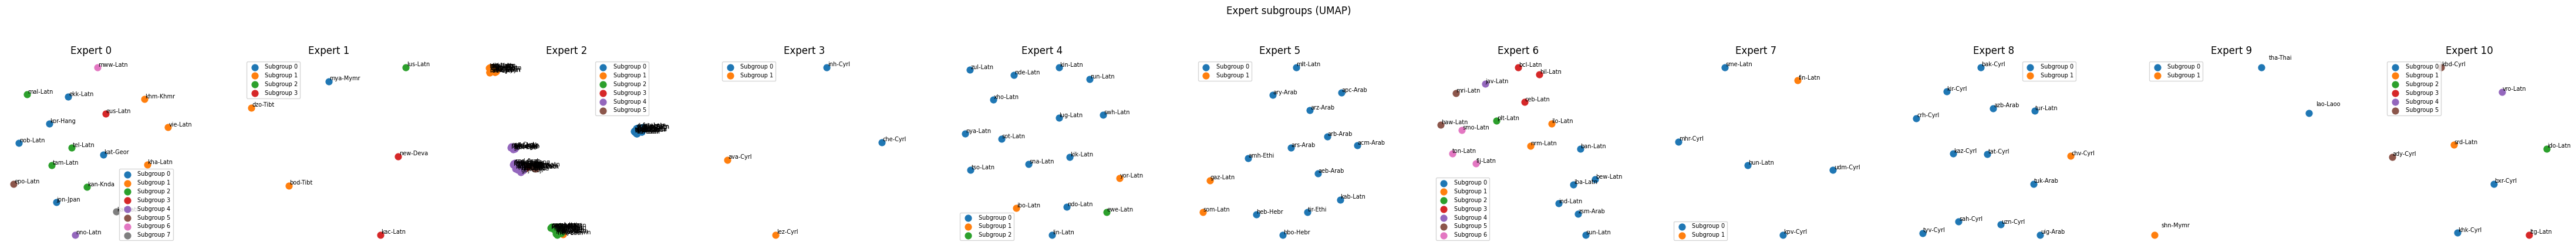

/scratch/hpc-prf-merlin/shared_cache/tmp/ipykernel_2875330/2299903704.py:70: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("tab10")


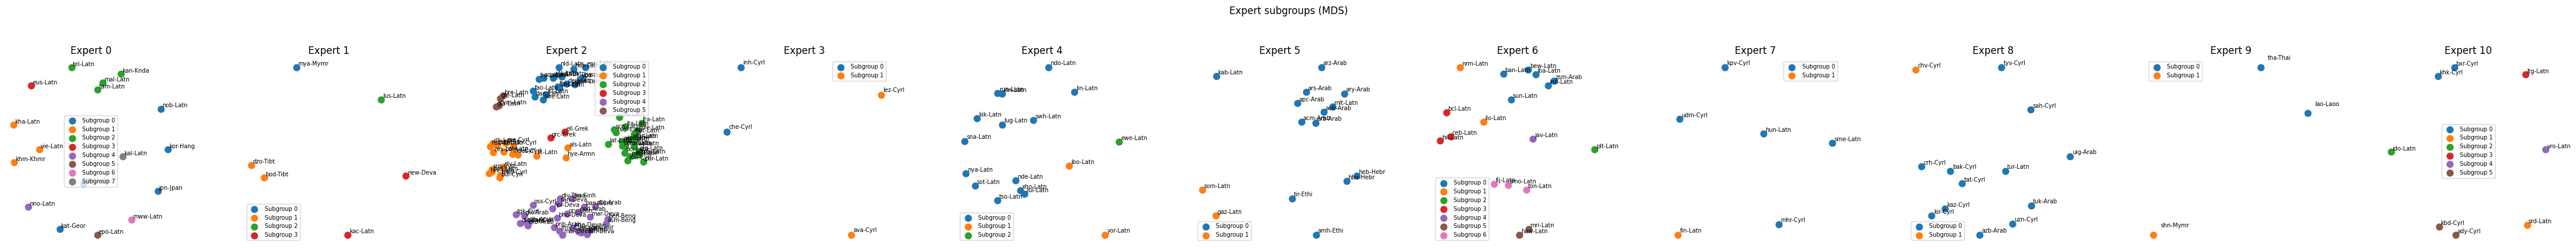

In [7]:
expert_subgroups = {}
for e_idx, exp_codes in experts.items():
    expert_subgroups[e_idx] = subcluster_expert(
        exp_codes,
        codes,
        matrix,
        k_max=12,
        min_subgroup_size=1,
    )

display_expert_subgroups(expert_subgroups, df)

plot_expert_subgroups(matrix, codes, expert_subgroups, df, method="umap")
plot_expert_subgroups(matrix, codes, expert_subgroups, df, method="mds")
save_groupings_json("200_tier_language_groupings.json", experts, expert_subgroups, df_out)


In [10]:
expert_stats = group_stats(experts, df)
display(expert_stats)
print("TOTAL docs (experts):", expert_stats.docs_sum.sum())


subgroup_flat = {
    f"E{e}_S{s}": sg
    for e, subs in expert_subgroups.items()
    for s, sg in enumerate(subs)
}

subgroup_stats = group_stats(subgroup_flat, df)
display(subgroup_stats)
print("TOTAL docs (subgroups):", subgroup_stats.docs_sum.sum())

# before saving
print("len codes" , len(set(codes)))                  # should be 200
print("len subsets", len(set(df.loc[df.code.isin(codes), "subset"])))  # ≈198

,group,n_langs,docs_sum,docs_mean,HIGH,MEDIUM,LOW,NaN
0,0,17,581505824,34206224,3,2,9,3
1,1,6,1854140,309023,0,0,6,0
2,2,91,29124175165,320045880,15,12,62,2
3,3,4,45051,11262,0,0,4,0
4,4,17,2556792,150399,0,0,17,0
5,5,15,82242259,5482817,2,0,13,0
6,6,18,102769329,5709407,1,0,16,1
7,7,6,86776078,14462679,2,0,4,0
8,8,13,101663617,7820278,1,1,8,3
9,9,3,36276043,12092014,1,0,2,0


TOTAL docs (experts): 30121567343


,group,n_langs,docs_sum,docs_mean,HIGH,MEDIUM,LOW,NaN
0,E0_S0,5,513082507,102616501,2,2,1,0
1,E0_S1,3,62680701,20893567,1,0,2,0
2,E0_S2,4,2423347,605836,0,0,1,3
3,E0_S3,1,1569434,1569434,0,0,1,0
4,E0_S4,1,1214870,1214870,0,0,1,0
5,E0_S5,1,335993,335993,0,0,1,0
6,E0_S6,1,158808,158808,0,0,1,0
7,E0_S7,1,40164,40164,0,0,1,0
8,E1_S0,1,1558304,1558304,0,0,1,0
9,E1_S1,2,180315,90157,0,0,2,0


TOTAL docs (subgroups): 30121567343
len codes 198
len subsets 227
